In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import pymysql
import datetime as dt

%matplotlib inline
sbn.set_style("whitegrid")

In [147]:
def extractData(action, myhost='127.0.0.1', myuser='root', mypassword='rootroot', databasename='transaction'):
    connection = pymysql.connect(host=myhost, user=myuser, password=mypassword, database=databasename)
    cursor = connection.cursor()
    query = action
    cursor.execute(action)
    features = [column[0] for column in cursor.description]
    cursor.close()
    connection.close()
    return pd.DataFrame(cursor.fetchall(), columns=features)

### Export to CSV

In [67]:
# extractData(action='SELECT * FROM customer_profile').to_csv('star_data/customer_profile.csv',index=False)
# extractData(action='SELECT * FROM product_profile').to_csv('star_data/product_profile.csv',index=False)
# extractData(action='SELECT * FROM order_profile').to_csv('star_data/order_profile.csv',index=False)

### Load the data

In [68]:
raw_data = extractData(action = 'SELECT * FROM transaction LEFT JOIN dim_customer USING(customer_id) \
LEFT JOIN dim_product USING(product_id) \
LEFT JOIN dim_time USING(transaction_id) \
LEFT JOIN dim_order USING(transaction_id)')
raw_data.head(1)

,transaction_id,product_id,customer_id,first_name,last_name,gender,num_prev_purchase,DOB,age,job_title,...,product_size,list_price,standard_cost,transaction_date,day_of_week,year,month,day,online_order,order_status
0,1,2,2950,Kristos,Anthony,Male,19,1955-01-11,68,Software Engineer I,...,medium,71.49,53.62,2017-02-25,Saturday,2017,2,25,FALSE,Approved


In [69]:
raw_data.shape

(19968, 30)

In [70]:
transaction = raw_data.copy()

In [71]:
transaction.dtypes

transaction_id        int64
product_id            int64
customer_id           int64
first_name           object
last_name            object
gender               object
num_prev_purchase    object
DOB                  object
age                   int64
job_title            object
job_industry         object
wealth_segment       object
owns_car             object
street               object
state                object
country              object
post_code             int64
brand                object
product_line         object
product_class        object
product_size         object
list_price           object
standard_cost        object
transaction_date     object
day_of_week          object
year                  int64
month                 int64
day                   int64
online_order         object
order_status         object
dtype: object

In [56]:
# data types conversion
transaction['num_prev_purchase'] = transaction['num_prev_purchase'].astype('Int64')
transaction['age'] = transaction['age'].astype('Int64')
transaction['list_price'] = transaction['list_price'].astype('Float64')
transaction['standard_cost'] = transaction['standard_cost'].astype('Float64')
transaction['transaction_date'] = pd.to_datetime(transaction['transaction_date'])
transaction['DOB'] = pd.to_datetime(transaction['DOB'])

# transaction.dtypes

In [73]:
# abnormality
transaction.loc[(transaction.gender == 'U').values, 'gender'] = np.nan
transaction.loc[(transaction.job_title == 'NA').values, 'job_title'] = np.nan
transaction.loc[(transaction.job_title == '').values, 'job_title'] = np.nan
transaction.loc[(transaction.job_industry == 'n/a').values, 'job_industry'] = np.nan
transaction.loc[(transaction.online_order == '').values, 'online_order'] = np.nan
transaction.loc[(transaction.age == 123).values, 'age'] = np.nan
transaction.loc[(transaction.age == 0).values, 'age'] = np.nan
transaction.isnull().sum()

transaction_id          0
product_id              0
customer_id             0
first_name              0
last_name               0
gender                455
num_prev_purchase       0
DOB                   446
age                   455
job_title            2379
job_industry         3222
wealth_segment          0
owns_car                0
street                  0
state                   0
country                 0
post_code               0
brand                   0
product_line            0
product_class           0
product_size            0
list_price              0
standard_cost           0
transaction_date        0
day_of_week             0
year                    0
month                   0
day                     0
online_order          359
order_status            0
dtype: int64

In [58]:
transaction.to_csv('../final_data/transaction.csv',index=False)

In [12]:
# new variables
transaction['age_group'] = 'teenager'
transaction.loc[(transaction.age > 18).values, 'age_group'] = 'early adulthood'
transaction.loc[(transaction.age > 34).values, 'age_group'] = 'middle adulthood'
transaction.loc[(transaction.age > 45).values, 'age_group'] = 'late adulthood'
transaction.loc[(transaction.age > 64).values, 'age_group'] = 'elder'

transaction['prev_purchase_cat'] = 'Previous purchase < 25'
transaction.loc[(transaction.num_prev_purchase > 24).values, 'prev_purchase_cat'] = 'Previous purchase 25-50'
transaction.loc[(transaction.num_prev_purchase > 49).values, 'prev_purchase_cat'] = 'Previous purchase 50-75'
transaction.loc[(transaction.num_prev_purchase > 74).values, 'prev_purchase_cat'] = 'Previous purchase > 75'

### EDA

/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:499: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:500: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


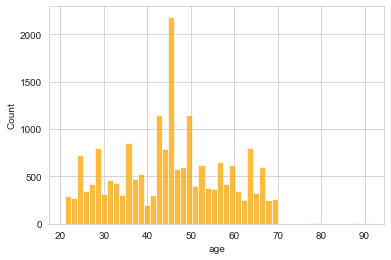

In [13]:
plt_age = sbn.histplot(transaction['age'], color='orange')

/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:499: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:500: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


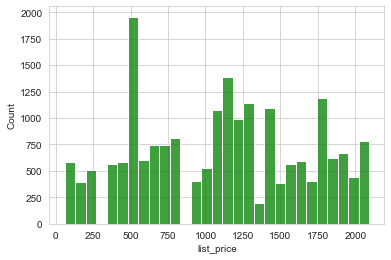

In [14]:
plt_price = sbn.histplot(transaction['list_price'], color='green')

/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:499: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:500: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


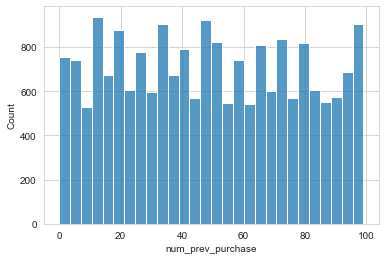

In [15]:
plt_prev_purchase = sbn.histplot(transaction['num_prev_purchase'])

/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:499: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/Users/chonge/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:500: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


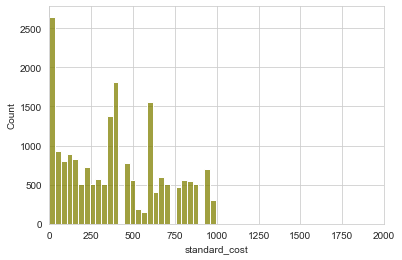

In [16]:
plt_cost = sbn.histplot(transaction['standard_cost'], color='olive').set_xlim(left=0, right=2000)

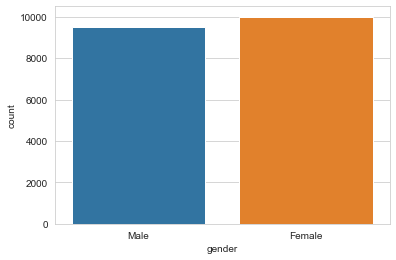

In [17]:
plt_gender = sbn.countplot(data=transaction,x='gender')

[Text(0, 0, 'Manufacturing'),
 Text(1, 0, 'Financial Services'),
 Text(2, 0, 'Health'),
 Text(3, 0, 'Retail'),
 Text(4, 0, 'Property'),
 Text(5, 0, 'IT'),
 Text(6, 0, 'Entertainment'),
 Text(7, 0, 'Agriculture'),
 Text(8, 0, 'Telecommunications')]

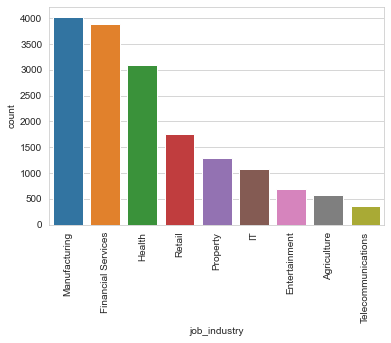

In [18]:
plt_job_industry = sbn.countplot(data=transaction,x='job_industry',order=transaction['job_industry'].value_counts().index)
plt_job_industry.set_xticklabels(plt_job_industry.get_xticklabels(),rotation=90)

[Text(0, 0, '19960'), Text(0, 0, '8')]

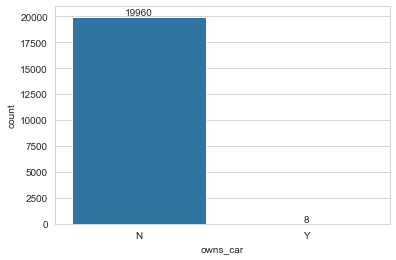

In [19]:
plt_own_car = sbn.countplot(data=transaction, x='owns_car')
values = transaction['owns_car'].value_counts(ascending=False).values

plt_own_car.bar_label(container=plt_own_car.containers[0], labels=values)

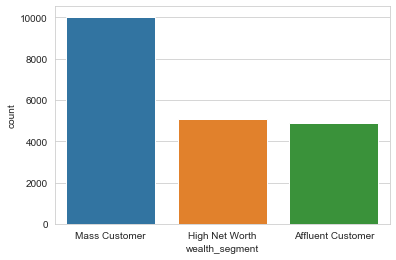

In [20]:
plt_wealth_seg = sbn.countplot(data=transaction,x='wealth_segment',order=transaction['wealth_segment'].value_counts().index)

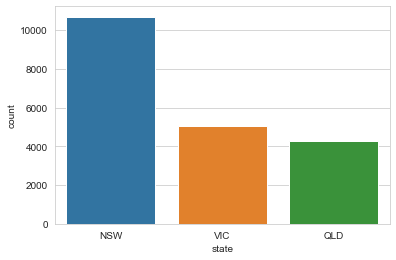

In [21]:
plt_wealth_seg = sbn.countplot(data=transaction,x='state',order=transaction['state'].value_counts().index)

[Text(0, 0, 'Solex'),
 Text(1, 0, 'WeareA2B'),
 Text(2, 0, 'Norco Bicycles'),
 Text(3, 0, 'Giant Bicycles'),
 Text(4, 0, 'Trek Bicycles'),
 Text(5, 0, 'OHM Cycles')]

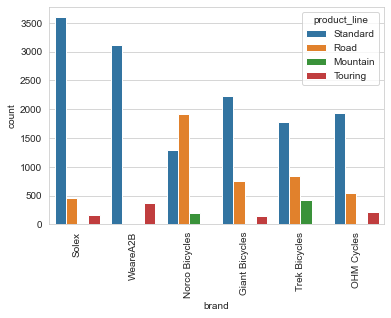

In [22]:
plt_brand_line = sbn.countplot(data=transaction,x='brand',order=transaction['brand'].value_counts().index, hue='product_line')
plt_brand_line.set_xticklabels(plt_brand_line.get_xticklabels(),rotation=90)

[Text(0, 0, 'Solex'),
 Text(1, 0, 'WeareA2B'),
 Text(2, 0, 'Norco Bicycles'),
 Text(3, 0, 'Giant Bicycles'),
 Text(4, 0, 'Trek Bicycles'),
 Text(5, 0, 'OHM Cycles')]

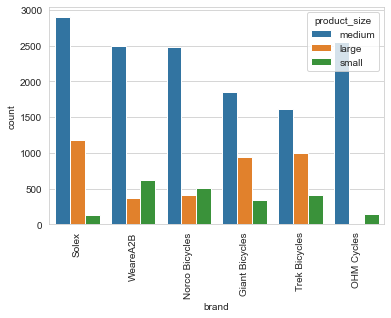

In [23]:
plt_brand_size = sbn.countplot(data=transaction,x='brand',order=transaction['brand'].value_counts().index, hue='product_size')
plt_brand_size.set_xticklabels(plt_brand_size.get_xticklabels(),rotation=90)

[Text(0, 0, 'Solex'),
 Text(1, 0, 'WeareA2B'),
 Text(2, 0, 'Norco Bicycles'),
 Text(3, 0, 'Giant Bicycles'),
 Text(4, 0, 'Trek Bicycles'),
 Text(5, 0, 'OHM Cycles')]

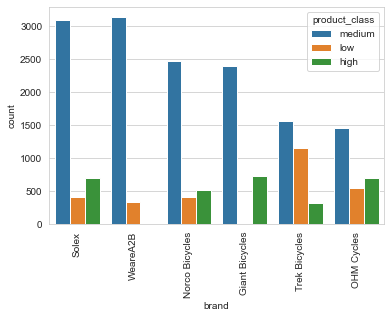

In [24]:
plt_brand_class = sbn.countplot(data=transaction,x='brand',order=transaction['brand'].value_counts().index, hue='product_class')
plt_brand_class.set_xticklabels(plt_brand_class.get_xticklabels(),rotation=90)

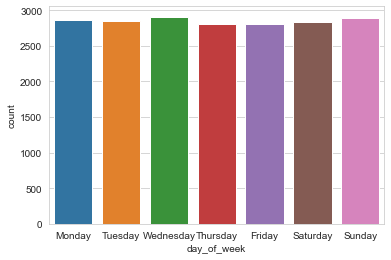

In [25]:
plt_dow = sbn.countplot(data=transaction,x='day_of_week',order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

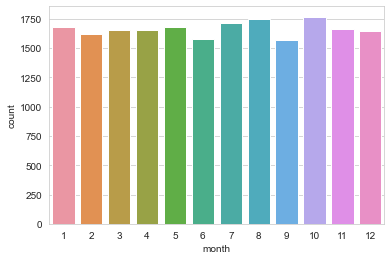

In [26]:
plt_month = sbn.countplot(data=transaction,x='month')

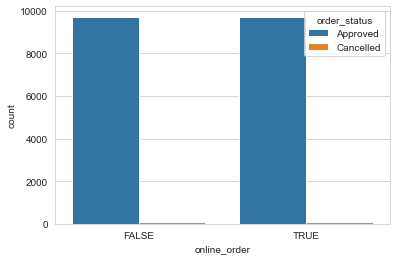

In [27]:
plt_month = sbn.countplot(data=transaction,x='online_order',hue='order_status')

In [28]:
transaction.columns

Index(['transaction_id', 'product_id', 'customer_id', 'first_name',
       'last_name', 'gender', 'num_prev_purchase', 'DOB', 'age', 'job_title',
       'job_industry', 'wealth_segment', 'owns_car', 'street', 'state',
       'country', 'post_code', 'brand', 'product_line', 'product_class',
       'product_size', 'list_price', 'standard_cost', 'transaction_date',
       'day_of_week', 'year', 'month', 'day', 'online_order', 'order_status',
       'age_group', 'prev_purchase_cat'],
      dtype='object')

[Text(0, 0, 'Solex'),
 Text(1, 0, 'Trek Bicycles'),
 Text(2, 0, 'OHM Cycles'),
 Text(3, 0, 'Norco Bicycles'),
 Text(4, 0, 'Giant Bicycles'),
 Text(5, 0, 'WeareA2B')]

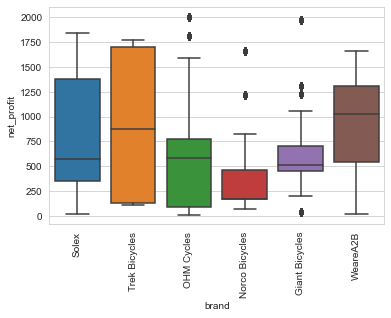

In [29]:
transaction['net_profit'] = transaction['list_price']-transaction['standard_cost']
plt_brand_profit = sbn.boxplot(data=transaction, x='brand', y='net_profit')
plt_brand_profit.set_xticklabels(plt_brand_profit.get_xticklabels(),rotation=90)

[Text(0, 0, 'Standard'),
 Text(1, 0, 'Road'),
 Text(2, 0, 'Mountain'),
 Text(3, 0, 'Touring')]

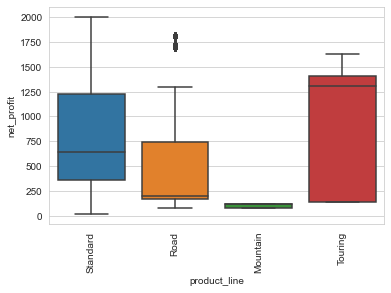

In [30]:
plt_prodline_profit = sbn.boxplot(data=transaction, x='product_line', y='net_profit')
plt_prodline_profit.set_xticklabels(plt_prodline_profit.get_xticklabels(),rotation=90)

[Text(0, 0, 'medium'), Text(1, 0, 'low'), Text(2, 0, 'high')]

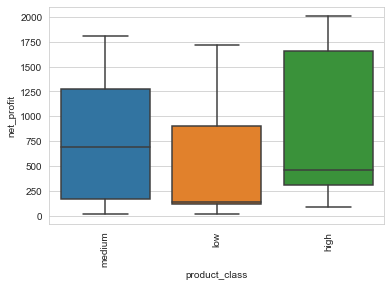

In [31]:
plt_prodclass_profit = sbn.boxplot(data=transaction, x='product_class', y='net_profit')
plt_prodclass_profit.set_xticklabels(plt_prodclass_profit.get_xticklabels(),rotation=90)

[Text(0, 0, 'FALSE'), Text(1, 0, 'TRUE')]

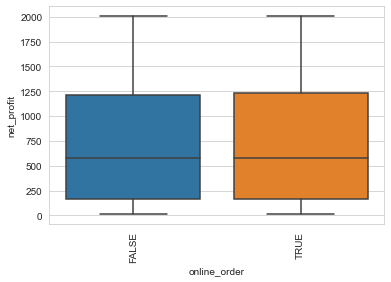

In [32]:
plt_online_profit = sbn.boxplot(data=transaction, x='online_order', y='net_profit')
plt_online_profit.set_xticklabels(plt_online_profit.get_xticklabels(),rotation=90)

/var/folders/l2/7wq9m36d0nvcw9qptmy_19fm0000gn/T/ipykernel_87766/1286960358.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(transaction['num_prev_purchase'])


<AxesSubplot: xlabel='num_prev_purchase', ylabel='Density'>

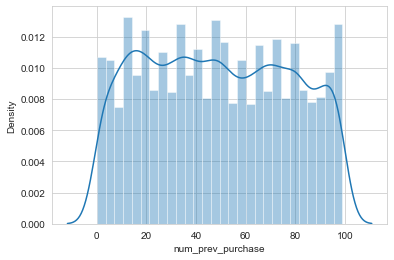

In [33]:
sbn.distplot(transaction['num_prev_purchase'])

In [34]:
# RFM
def rfm(data, target, price='list_price'):
    snapshot_date = data['transaction_date'].max() + dt.timedelta(days=1)
    rfm_table = data.groupby(target).agg({
        'transaction_date': lambda x: (snapshot_date - x.max()).days,
        'transaction_id': 'count',
        price: 'sum'
    })
    rfm_table.rename(columns={
        'transaction_date': 'Recency',
        'transaction_id': 'Frequency',
        price: 'Monetary'
    }, inplace=True)

    rfm_table['R_rank'] = rfm_table['Recency'].rank(ascending=False)
    rfm_table['F_rank'] = rfm_table['Frequency'].rank(ascending=True)
    rfm_table['M_rank'] = rfm_table['Monetary'].rank(ascending=True)

    # normalizing the rank of the customers
    rfm_table['R_rank_norm'] = (rfm_table['R_rank']/rfm_table['R_rank'].max())*100
    rfm_table['F_rank_norm'] = (rfm_table['F_rank']/rfm_table['F_rank'].max())*100
    rfm_table['M_rank_norm'] = (rfm_table['F_rank']/rfm_table['M_rank'].max())*100

    rfm_table.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

    rfm_table['RFM_Score'] = 0.15*rfm_table['R_rank_norm']+0.40 * \
        rfm_table['F_rank_norm']+0.45*rfm_table['M_rank_norm']
    rfm_table['RFM_Score'] *= 0.05
    rfm_table = rfm_table.round(2)
    rfm_table.sort_values('RFM_Score', ascending=False,inplace=True)

    rfm_table["Segments"] = np.where(rfm_table['RFM_Score'] >
                                          4.5, "Top",
                                          (np.where(
                                            rfm_table['RFM_Score'] > 4,
                                            "High value",
                                            (np.where(
        rfm_table['RFM_Score'] > 3,
                                 "Medium Value",
                                 np.where(rfm_table['RFM_Score'] > 1.6,
                                'Low Value', 'At Risk'))))))
    return rfm_table

In [35]:
rfm_table_customer = rfm(data=transaction, target='customer_id')
rfm_table_customer.head(10)

,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Segments
customer_id,,,,,,,,
2464,3,13,15429.89,97.03,99.73,99.70,4.97,Top
2659,1,12,11229.05,100.00,99.10,99.07,4.96,Top
2548,4,13,15860.98,95.50,99.73,99.70,4.95,Top
1068,5,14,15269.55,94.04,100.00,99.97,4.95,Top
322,2,12,15872.04,98.59,99.10,99.07,4.95,Top
3048,5,13,17224.97,94.04,99.73,99.70,4.94,Top
377,7,13,13267.9,91.19,99.73,99.70,4.92,Top
1140,7,13,17199.72,91.19,99.73,99.70,4.92,Top
25,6,12,11450.33,92.54,99.10,99.07,4.91,Top


[Text(0, 0, 'Top'),
 Text(1, 0, 'High value'),
 Text(2, 0, 'Medium Value'),
 Text(3, 0, 'Low Value'),
 Text(4, 0, 'At Risk')]

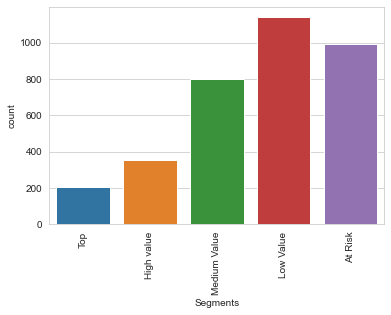

In [36]:
plt_customer_seg = sbn.countplot(data=rfm_table_customer, x='Segments')
plt_customer_seg.set_xticklabels(plt_customer_seg.get_xticklabels(),rotation=90)

In [37]:
extractData(action = 'SELECT * FROM customer_profile WHERE customer_id in '+str(rfm_table_customer.index[0:10].to_list()).replace('[','(').replace(']',')'))

,customer_id,first_name,last_name,gender,num_prev_purchase,DOB,age,job_title,job_industry,wealth_segment,owns_car,street,state,country,post_code,num_purchase,total_purchase
0,25,Geoff,Assaf,Male,72,1976-12-02,46,Accounting Assistant III,Financial Services,Mass Customer,N,28 5th Center,QLD,Australia,4413,12,11450.33
1,322,De,Denington,Female,19,1977-03-10,46,Research Associate,Financial Services,Mass Customer,N,5 Schurz Place,QLD,Australia,4350,12,15872.04
2,377,Levy,Bonavia,Male,65,1999-05-19,24,Staff Scientist,Agriculture,Mass Customer,N,259 Barnett Crossing,NSW,Australia,2265,13,13267.90
3,1068,Frazer,Searston,Male,5,1995-03-21,28,NA,Health,Mass Customer,N,4297 Emmet Lane,NSW,Australia,2170,14,15269.55
4,1140,Deana,Rathbourne,Female,32,1986-02-25,37,Executive Secretary,n/a,Mass Customer,N,8587 Graceland Way,NSW,Australia,2206,13,17199.72
5,2183,Jillie,Fyndon,Female,61,1972-02-07,51,Programmer Analyst IV,Manufacturing,Mass Customer,N,8142 Tomscot Drive,QLD,Australia,4132,14,19593.05
6,2464,Cleve,Jindrak,Male,78,1983-04-06,40,Speech Pathologist,Retail,Mass Customer,N,3126 Butterfield Pass,NSW,Australia,2573,13,15429.89
7,2548,Kristien,Robberts,Female,11,1971-07-30,51,Chief Design Engineer,n/a,Mass Customer,N,12 Fairfield Parkway,VIC,Australia,3029,13,15860.98
8,2659,Konstance,Elgey,Female,81,1974-06-14,49,Professor,Agriculture,High Net Worth,N,882 Mitchell Place,QLD,Australia,4151,12,11229.05
9,3048,Kenon,Messruther,Male,38,1969-05-27,54,Legal Assistant,Manufacturing,Mass Customer,N,80302 Stang Parkway,VIC,Australia,3677,13,17224.97


In [38]:
rfm_table_product = rfm(data=transaction, target='product_id')
rfm_table_product.head(10)

,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Segments
product_id,,,,,,,,
0,1,1372,746436.6,100.00,100.00,100.00,5.00,Top
3,1,354,740380.38,100.00,99.01,99.01,4.96,Top
1,1,311,436488.5,100.00,98.02,98.02,4.92,Top
4,1,241,272120.33,100.00,95.05,95.05,4.79,Top
2,1,240,17157.6,100.00,94.06,94.06,4.75,Top
90,1,224,81314.24,100.00,92.57,92.57,4.68,Top
12,1,224,275777.6,100.00,92.57,92.57,4.68,Top
80,1,223,239294.61,100.00,91.09,91.09,4.62,Top
35,2,268,283412.68,59.64,97.03,97.03,4.57,Top


[Text(0, 0, 'Top'),
 Text(1, 0, 'High value'),
 Text(2, 0, 'Medium Value'),
 Text(3, 0, 'Low Value'),
 Text(4, 0, 'At Risk')]

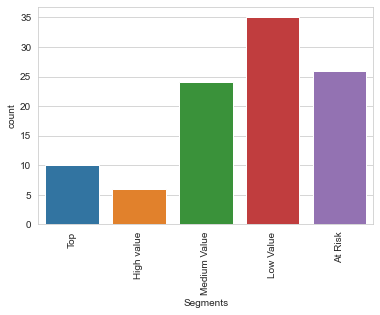

In [39]:
plt_product_seg = sbn.countplot(data=rfm_table_product, x='Segments')
plt_product_seg.set_xticklabels(plt_product_seg.get_xticklabels(),rotation=90)

In [40]:
extractData(action = 'SELECT * FROM product_profile WHERE product_id in '+str(rfm_table_product.index[0:10].to_list()).replace('[','(').replace(']',')'))

,product_id,brand,product_line,product_class,product_size,list_price,standard_cost,num_purchase,net_profit,total_profit
0,0,Norco Bicycles,Road,medium,medium,544.05,376.84,1372,167.21,229412.12
1,1,Giant Bicycles,Standard,medium,medium,1403.50,954.82,311,448.68,139539.48
2,2,Solex,Standard,medium,medium,71.49,53.62,240,17.87,4288.80
3,3,Trek Bicycles,Standard,medium,large,2091.47,388.92,354,1702.55,602702.70
4,4,Giant Bicycles,Standard,high,medium,1129.13,677.48,241,451.65,108847.65
5,12,WeareA2B,Standard,medium,medium,1231.15,161.60,224,1069.55,239579.20
6,35,Trek Bicycles,Standard,low,medium,1057.51,154.40,268,903.11,242033.48
7,38,Trek Bicycles,Standard,medium,large,2091.47,388.92,266,1702.55,452878.30
8,80,OHM Cycles,Touring,low,medium,1073.07,933.84,223,139.23,31048.29
9,90,Norco Bicycles,Standard,low,medium,363.01,290.41,224,72.60,16262.40


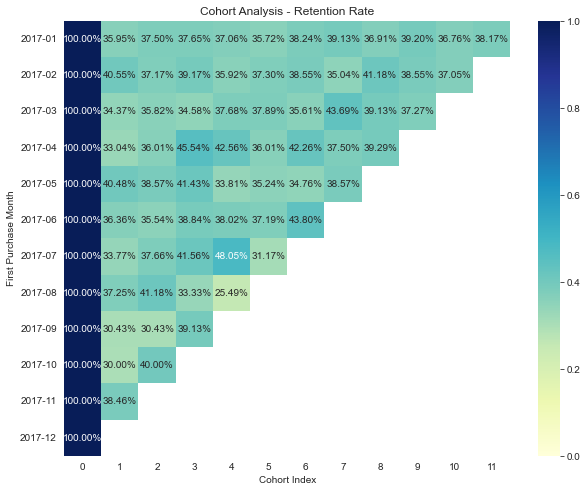

In [41]:
# cohort analysis
cohort_temp = transaction.copy()
cohort_temp['first_purchase_month'] = cohort_temp.groupby('customer_id')['transaction_date'].transform('min').dt.to_period('M')

cohort_temp['cohort_index'] = (cohort_temp['transaction_date'].dt.to_period('M') - cohort_temp['first_purchase_month']).apply(lambda x: x.n)

cohort_data = cohort_temp.groupby(['first_purchase_month', 'cohort_index']).agg({
    'customer_id': 'nunique',  # Count unique customers
    'transaction_id': 'count'  # Count transactions
})

cohort_data['retention_rate'] = cohort_data['customer_id'] / cohort_data.groupby('first_purchase_month')['customer_id'].transform('first')

cohort_pivot = cohort_data.pivot_table(index='first_purchase_month', columns='cohort_index', values='retention_rate')

plt.figure(figsize=(10, 8))
plt.title('Cohort Analysis - Retention Rate')
sbn.heatmap(cohort_pivot, annot=True, cmap='YlGnBu', fmt='.2%', vmin=0.0, vmax=1.0, cbar=True)
plt.xlabel('Cohort Index')
plt.ylabel('First Purchase Month')
plt.show()

In [42]:
def cohort_analysis(data, cohort_var_lst, yticks=[0,1,0.1]):    
    df = data.copy()
    # Define the cohorts based on multiple features (e.g., gender and wealth segment)
    df['cohort'] = df[cohort_var_lst[0]]
    if len(cohort_var_lst) > 1:
        for i in cohort_var_lst[1:]:
            df['cohort'] = df['cohort'] + '-' + df[i]

    # Calculate the cohort size (number of unique customers in each cohort)
    cohort_sizes = df.groupby('cohort')['customer_id'].nunique()

    # Calculate the monthly retention rate for each cohort
    retention_matrix = df.pivot_table(index='cohort', columns='month', values='customer_id', aggfunc='nunique')
    retention_rate = retention_matrix.divide(cohort_sizes, axis=0)
    retention_rate = retention_rate.T
    retention_rate['months in 2017'] = retention_rate.index
    retention_rate = retention_rate.melt(id_vars='months in 2017', var_name='cohort', value_name='retention rate')
    # Plot the cohort analysis line chart
    figure = sbn.lineplot(data=retention_rate, x='months in 2017', y='retention rate', hue='cohort')
    figure.set_xticks(range(1,13))
    figure.set_yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

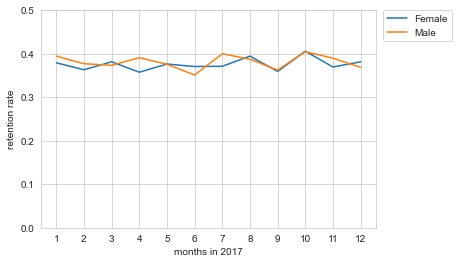

In [43]:
cohort_analysis(transaction,['gender'],[0,0.6,0.1])

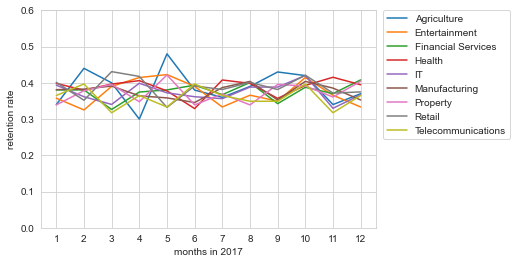

In [44]:
cohort_analysis(transaction,['job_industry'],[0,0.7,0.1])

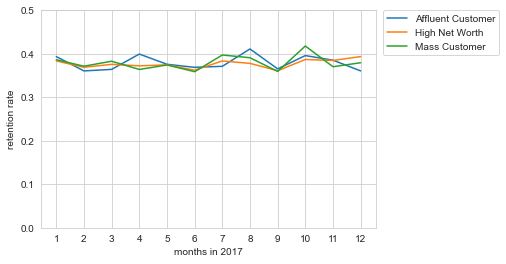

In [45]:
cohort_analysis(transaction,['wealth_segment'],[0,0.6,0.1])

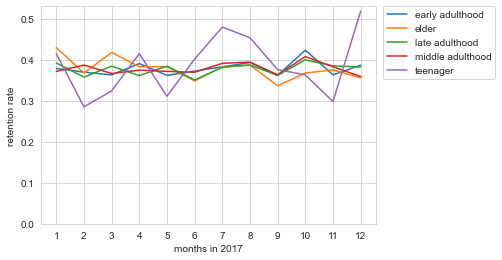

In [46]:
cohort_analysis(transaction,['age_group'],[0,0.6,0.1])

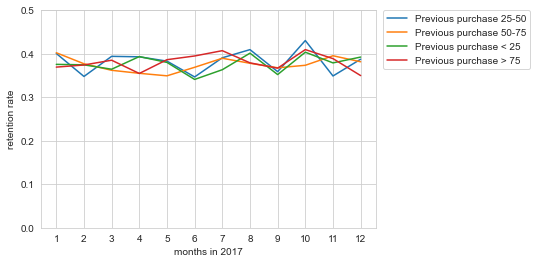

In [47]:
cohort_analysis(transaction,['prev_purchase_cat'],[0,0.6,0.1])